In [1]:
import matplotlib.pyplot as plt

from jacinta.utils.scheduler import (
    ExponentialScheduler,
    PiecewiseScheduler,
    PolynomialScheduler,
    PowerScheduler,
)

In [2]:
# hyperparameters
SEGMENTS = (
    (
        0,
        PowerScheduler(
            scale=10,
            exponent=0.5,
            offset=0,
            intercept=0,
            min_value=0,
            max_value=1000,
        ),
    ),
    (
        2500,
        PolynomialScheduler(
            coefficients=(125, 0.2, -0.00002),
            min_value=0,
            max_value=1000,
        ),
    ),
    (
        7500,
        ExponentialScheduler(
            scale=2241,
            rate=-0.0002,
            intercept=0,
            min_value=0,
            max_value=1000,
        ),
    ),
)

# plot parameters
MAX_DEPTH = 10000

In [3]:
def plot_scheduler(
    ax: plt.Axes,
    scheduler: PiecewiseScheduler,
) -> None:
    """
    Plot a scheduler.

    Args:
        ax (plt.Axes): The axes to plot on.
        scheduler (PiecewiseScheduler): The scheduler to plot.
    """
    # evaluate the scheduler
    depths = list(range(MAX_DEPTH + 1))
    values = [scheduler(depth) for depth in depths]
    # plot the scheduler
    ax.plot(depths, values)
    ax.set_xlim(0, MAX_DEPTH)
    ax.set_xlabel("Depth")
    ax.set_ylabel("Value")
    ax.set_title("Piecewise Scheduler")
    ax.grid(visible=True, alpha=0.3)
    return

In [4]:
# initialize a PiecewiseScheduler
scheduler = PiecewiseScheduler(
    segments=SEGMENTS,
)

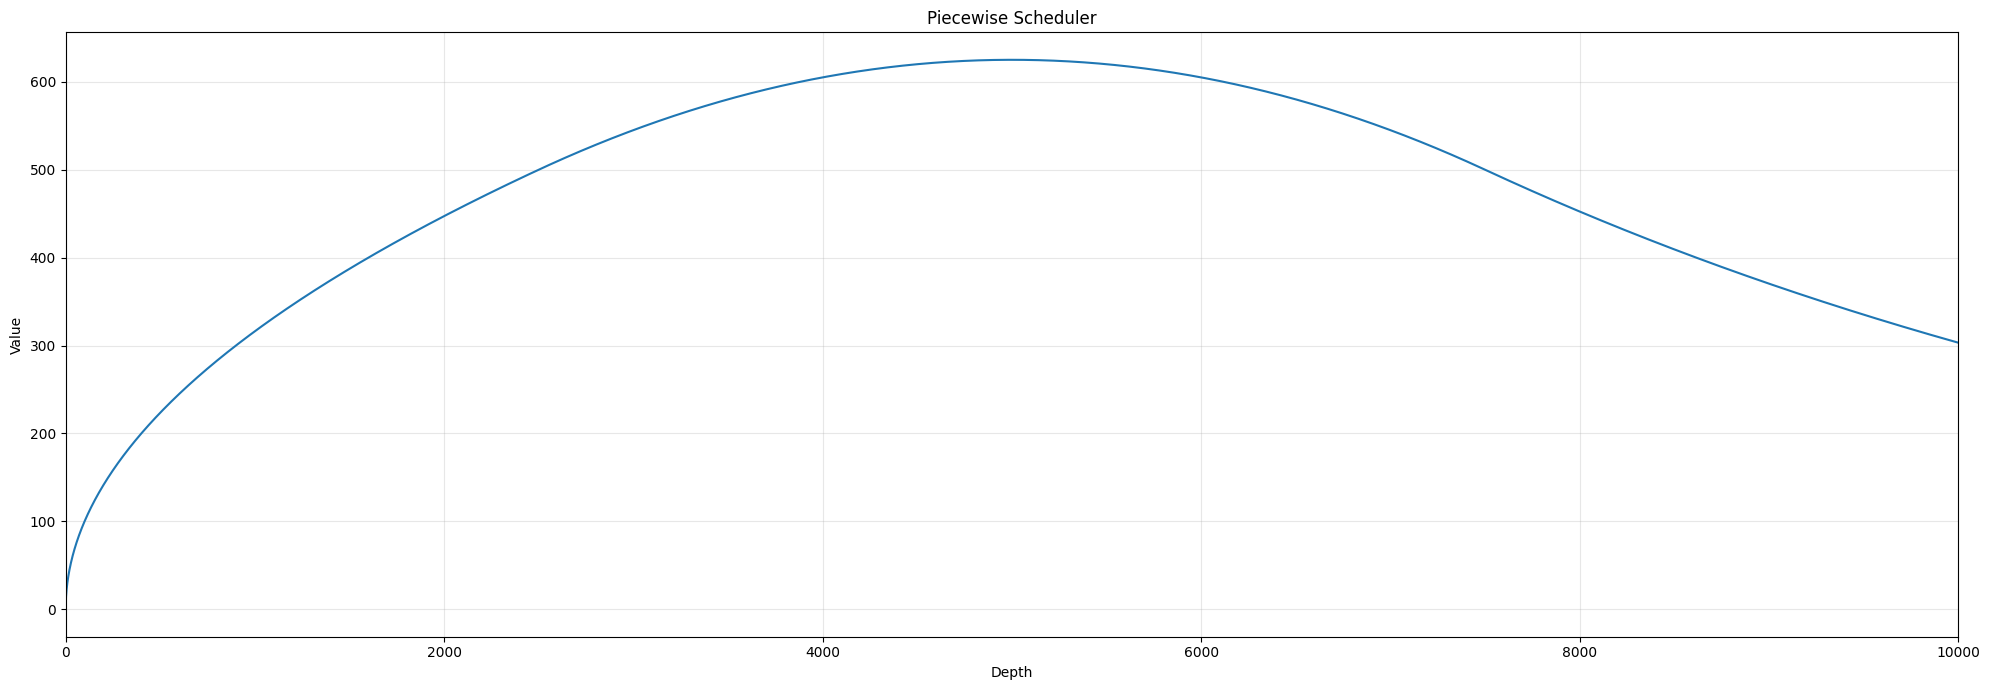

In [5]:
# plot the scheduler
fig, ax = plt.subplots(figsize=(20, 7))
plot_scheduler(ax, scheduler)
fig.tight_layout()
plt.show()